# Formula 1 Constructor Performance, 1981–2020
**DATASCI 530 — Assignment 2 · Whitney Barr**

**Summary of findings:**
- Ferrari, Mercedes, and McLaren earned the most points of any constructor between 1981 and 2020, each scoring roughly 10–14x the 67-constructor average.
- Over 2001–2020, Red Bull displaces McLaren for third place while Ferrari and Mercedes still lead.
- McLaren's success sits mostly in the 1980s–1990s, while Mercedes and Red Bull didn't hit their championship-level point status until after 2009.
- Ferrari had 25 different drivers between 1981 and 2020 and had the best season by points was 2018 with 571 points.

- New insight: points-per-win varies 2–3x across constructors.


**Data sources**: Formula 1 dataset and respective codebook provided. There are 16 datasets within this folder.

## a): Top 3 constructors, 1981–2020
I joined constructor_results to races and constructors,
filtered years to 1981–2020, then summed points by team (also known as conductors). Finally, I put the points in descending order and selected the top 3 using the head function.

I used the following datasets:
- **Constructors** - constructorRef for constructor names; this dataset connects **constructor names** to constructorId
- **Constructor results** - this dataset shows **points** constructors (constructorId) earned in each race (raceId)
- **Races** - years; this dataset lists each season also known as **year** with their respective races throughout the season (raceId)





First, I imported the library.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt


Second, I imported the needed datasets (csv files) using **pd.read_csv** function.

In [ ]:
constructor_results   = pd.read_csv(r"C:\Users\Owner\Documents\GitHub\datasci530fall2026\Lecture 03\data_raw\constructor_results.csv")
races = pd.read_csv(r"C:\Users\Owner\Documents\GitHub\datasci530fall2026\Lecture 03\data_raw\races.csv")
constructors = pd.read_csv(r"C:\Users\Owner\Documents\GitHub\datasci530fall2026\Lecture 03\data_raw\constructors.csv")




### Quality checks

Before joining the datasets, I checked the following:
1. No missing values in the columns I'm about to join on.
2. Every row finds a match after the join (no blanks).

In [31]:
constructors = constructors[["constructorId", "constructorRef", "name", "nationality"]]

In [32]:
print("Missing values check:")
print(constructor_results[["raceId", "constructorId", "points"]].isna().sum())

Missing values check:
raceId           0
constructorId    0
points           0
dtype: int64


In [44]:
print("\nRows before merge:", len(constructor_results))
print("Rows after merge:  ", len(merged))
print("Missing year after merge:", merged["year"].isna().sum())
print("Missing name after merge:", merged["name"].isna().sum())


Rows before merge: 12170
Rows after merge:   12170
Missing year after merge: 0
Missing name after merge: 0


Since **rows are the same** before and after merge and **there are no missing years or names after the merge**, quality of the data has been preserved and we can now do a **merge**. Again, the merge is being done in order to bring constructor ids, constructor names, years, and points into one dataset before sorting and filtering for top 3.

In [36]:
merged_step1 = pd.merge(constructor_results, races[["raceId", "year", "round"]], on="raceId", how="left")
merged = pd.merge(merged_step1, constructors, on="constructorId", how="left")

In [37]:
time_period_81_20 = merged[merged["year"].between(1981, 2020)]

totals_81_20 = (
    time_period_81_20
    .groupby("name")["points"]
    .sum()
    .sort_values(ascending=False)
)

The merge was completed successfully. The next step is to total the **points** by **name** of Constructors in descending order. 
After grouping **points** by **constructor name**,I used the average and len functions in order to determine the average points across all constructors.

In [ ]:
comparison["rank_1981_2020"] = comparison["points_1981_2020"].rank(method="dense", ascending=False)

In [47]:

totals_81_20 = (
    time_period_81_20
    .groupby("name")["points"]
    .sum()
    .sort_values(ascending=False)
)

avg_a = totals_81_20.mean()

print(f"Average points across all {len(totals_81_20)} constructors: {avg_a:.1f}")
totals_81_20.head(3)

Average points across all 67 constructors: 532.2


name
Ferrari     7374.0
Mercedes    5685.0
McLaren     5229.5
Name: points, dtype: float64

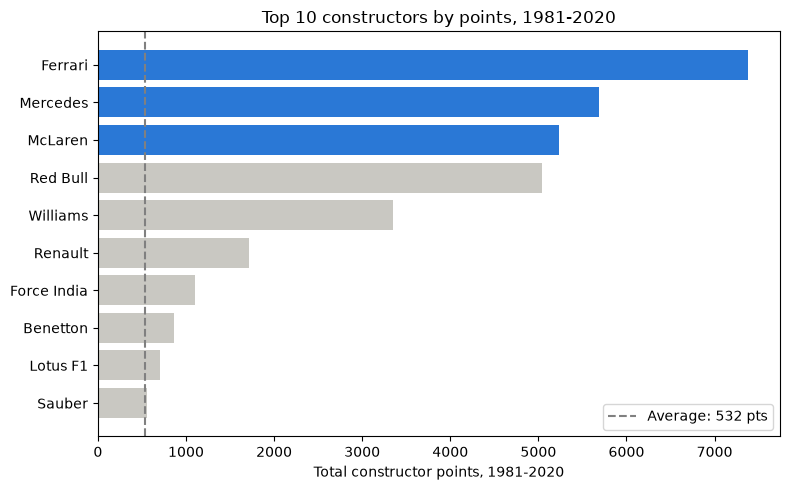

In [51]:
top10_a = totals_81_20.head(10)
colors = []
for i in range(len(top10_a)):
    if i < 3:
      colors.append("#2a78d6")
    else:
        colors.append("#c9c8c2")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10_a.index[::-1], top10_a.values[::-1], color=colors[::-1])
ax.axvline(avg_a, color="gray", linestyle="--", label=f"Average: {avg_a:.0f} pts")
ax.set_xlabel("Total constructor points, 1981-2020")
ax.set_title("Top 10 constructors by points, 1981-2020")
ax.legend()
plt.tight_layout()
plt.show()

## data response for a


Based on the table above, Ferrari, Mercedes, and McLaren were the top 3 constructors, based on points, from 1981-2020.
67 constructors scored at least one point in this window, and the average total across
all of them was 532.2 points. The top three leaders earned atleast 10x more than the average.

# b) Which three constructors earned the most points between 2001 and 2020? How many total points did each of them earn? How do the total points for each constructor compare with the average across constructors?

In order to answer this question, the workflow used in response a will work. The time period needs to be adjusted to 2001 to 2020. After adjusting for time, the groupby, sum, sort, average, and head functions were used as done previously in a. Head is used to specify the # of rows, in this case, that should be included in the top selection. Since the ask is for top 3, totals_b.head(3) will work.


In [52]:
period_b = merged[merged["year"].between(2001, 2020)]
colors_b = []
for i in range(len(top10_b)):
    if i < 3:
        colors_b.append("#2a78d6")
    else:
        colors_b.append("#c9c8c2")
totals_b = (
    period_b
    .groupby("name")["points"]
    .sum()
    .sort_values(ascending=False)
)

avg_b = totals_b.mean()
print(f"Average points across all {len(totals_b)} constructors: {avg_b:.1f}")
totals_b.head(3)

Average points across all 35 constructors: 786.0


name
Ferrari     5862.0
Mercedes    5685.0
Red Bull    5043.5
Name: points, dtype: float64

From 2001 to 2020, there were 35 Constructors with an **average of 786.0 points**. 
The 2001–2020 average comes out higher (786.0 points vs. 532.2 for the full timeframe).
**Ferrari, Mercedes, and Red Bull** respectively earned 5862.0, 5685.0, and 5043.5 points. All of the top 3 earned 6-7x more than the average of 786 points. 
Across the top 3, **16,590.5 points** were earned.

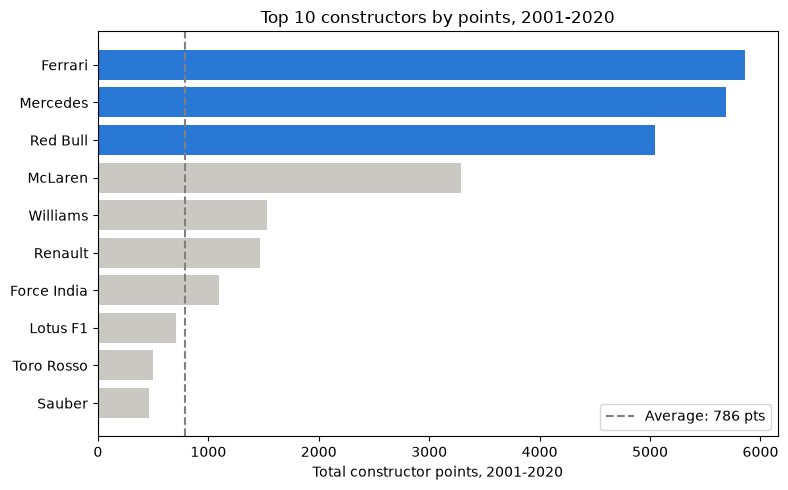

In [ ]:
top10_b = totals_b.head(10)
d

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10_b.index[::-1], top10_b.values[::-1], color=colors_b[::-1])
ax.axvline(avg_b, color="gray", linestyle="--", label=f"Average: {avg_b:.0f} pts")
ax.set_xlabel("Total constructor points, 2001-2020")
ax.set_title("Top 10 constructors by points, 2001-2020")
ax.legend()
plt.tight_layout()
plt.show()

# c) How did the rankings change across the two time periods?
 The head, index, and comparison functions are key to finding these answers. The top 8 constructors (by name) were indexed and named the top_names. Then points were indexed in descending order across both time periods.

In [49]:
top_names = totals_81_20.head(8).index.tolist()

comparison = pd.DataFrame({
    "points_1981_2020": totals_81_20.reindex(top_names),
    "rank_1981_2020": totals_81_20.rank(ascending=False, method="min").reindex(top_names),
    "points_2001_2020": totals_b.reindex(top_names).fillna(0),
    "rank_2001_2020": totals_b.rank(ascending=False, method="min").reindex(top_names),
})
comparison

,points_1981_2020,rank_1981_2020,points_2001_2020,rank_2001_2020
name,,,,
Ferrari,7374.0,1.0,5862.0,1.0
Mercedes,5685.0,2.0,5685.0,2.0
McLaren,5229.5,3.0,3284.0,4.0
Red Bull,5043.5,4.0,5043.5,3.0
Williams,3355.0,5.0,1535.5,5.0
Renault,1710.0,6.0,1465.0,6.0
Force India,1098.0,7.0,1098.0,7.0
Benetton,861.5,8.0,10.0,22.0


# c) data observations
Ferrari and Mercedes hold onto the top two spots in both windows. McLaren and Red Bull
swap places for third. Red Bull and Mercedes, on the other hand, have identical point totals in both time periods.

# d) How many different drivers did Ferrari have between 1981 and 2020?
First, I read the CSV files, merged files, and checked for errors with the merge. Then I used the nunique function for **driver id** in order to find the number of Ferrari drivers between 1981 and 2020.

In [ ]:

constructor_standings = pd.read_csv(r"C:\Users\Owner\Documents\GitHub\datasci530fall2026\Lecture 03\data_raw\constructor_standings.csv")
results               = pd.read_csv(r"C:\Users\Owner\Documents\GitHub\datasci530fall2026\Lecture 03\data_raw\results.csv")

print("Unique resultId vs row count:", results["resultId"].nunique(), len(results))

results_merged = (
    results
    .merge(races[["raceId", "year"]], on="raceId", how="left")
    .merge(constructors[["constructorId", "name"]], on="constructorId", how="left")
)
print("Missing year after merge:", results_merged["year"].isna().sum())
print("Missing name after merge:", results_merged["name"].isna().sum())

ferrari_id = constructors.loc[constructors["name"] == "Ferrari", "constructorId"].iloc[0]

ferrari_period = results_merged[
    (results_merged["constructorId"] == ferrari_id)
    & (results_merged["year"].between(1981, 2020))
]

n_ferrari_drivers = ferrari_period["driverId"].nunique()
print("\nDistinct Ferrari drivers, 1981-2020:", n_ferrari_drivers)

Unique resultId vs row count: 25840 25840
Missing year after merge: 0
Missing name after merge: 0

Distinct Ferrari drivers, 1981-2020: 25


# d) data observations 
Ferrari fielded 25 different drivers between 1981 and 2020. Turnover was highest in
the early-to-mid 1980s and again from the mid-2000s into the early 2010s, and lowest during
Ferrari's most stable, successful stretches from 2001- 2005 when they had just 2 drivers.

# e) What was the best year for Ferrari between 1981 and 2020?

In order to determine the best year, descending **points** were examined by year and filtered to just Ferrari. The same time period is used from part a (1981- 2020). The **best points** variable was found using the **head** function.**Max** function would have also worked.


In [43]:
ferrari_by_year = (
   ferrari_period[ferrari_period["name"] == "Ferrari"]
    .groupby("year")["points"]
    .sum()
    .sort_index()
)

ferrari_by_year = (
   ferrari_period[ferrari_period["name"] == "Ferrari"]
    .groupby("year")["points"]
    .sum()
)

ferrari_by_year.sort_values(ascending=False).head(1)

year
2018    571.0
Name: points, dtype: float64

# e) data observations
Ferrari's best year was in 2018 when they reached their highest point sum of 571 points. 2015–2019 was a strong time period for Ferrari with every season exceeding close to 400 points annually. Ferrari's weakest seasons were in the early 1990s.

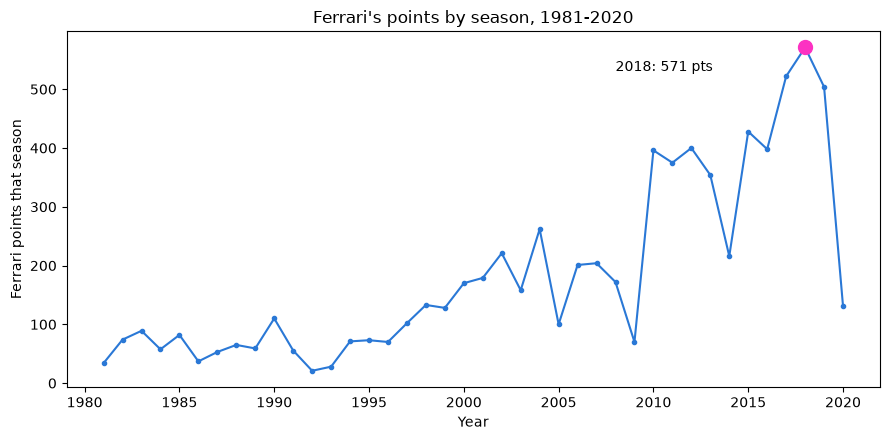

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ferrari_by_year.index, ferrari_by_year.values, color="#2a78d6", marker="o", markersize=3)
ax.scatter([best_year], [best_points], color="#fc32c2", s=100, zorder=5)
ax.annotate(f"{best_year}: {best_points:.0f} pts", (best_year, best_points),
            xytext=(best_year - 10, best_points - 40))
ax.set_xlabel("Year")
ax.set_ylabel("Ferrari points that season")
ax.set_title("Ferrari's points by season, 1981-2020")
plt.tight_layout()
plt.show()